PART A DATA PREPARATION


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1048s 6us/step
Training images: (45000, 32, 32, 3)
Validation images: (5000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


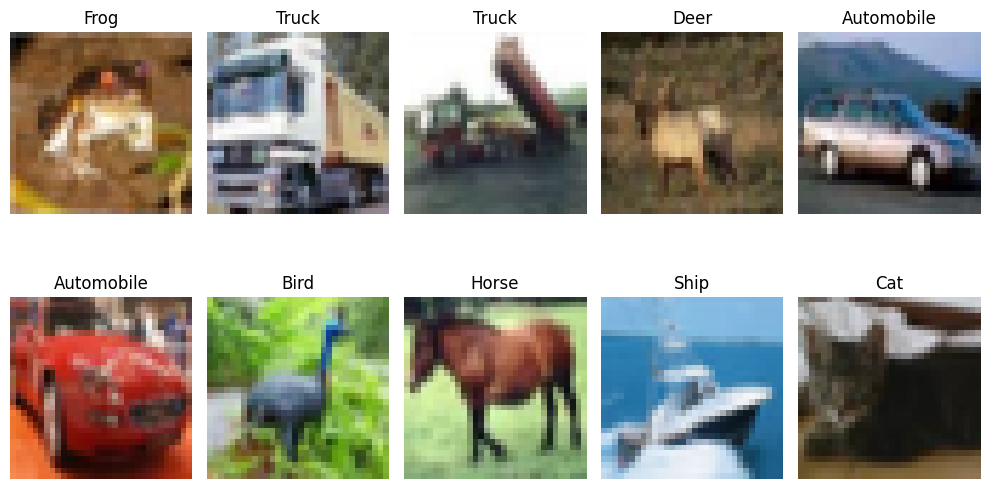

In [1]:
# ============================================================
# CNN IMAGE CLASSIFICATION
# TASK A: DATASET PREPARATION
# Name     : VETTRI SELVAN D
# Roll No  : 24BAD127
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize image pixel values
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create training and validation datasets
x_train = x_train_full[:45000]
y_train = y_train_full[:45000]

x_val = x_train_full[45000:]
y_val = y_train_full[45000:]

# Class names
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

# Display dataset information
print("Training images:", x_train.shape)
print("Validation images:", x_val.shape)
print("Testing images:", x_test.shape)

# Display sample images
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

PART B

In [2]:
# ============================================================
# CNN IMAGE CLASSIFICATION
# TASK B: CNN MODEL IMPLEMENTATION
# Name     :  VETTRI SELVAN D
# Roll No  : 24BAD127
# ============================================================

import tensorflow as tf

# Create CNN model
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

PART C

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 82ms/step - accuracy: 0.3997 - loss: 1.6497 - val_accuracy: 0.4978 - val_loss: 1.3961
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.5410 - loss: 1.2919 - val_accuracy: 0.5720 - val_loss: 1.2144
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.5988 - loss: 1.1435 - val_accuracy: 0.6188 - val_loss: 1.1001
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.6308 - loss: 1.0514 - val_accuracy: 0.6420 - val_loss: 1.0155
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.6565 - loss: 0.9753 - val_accuracy: 0.6312 - val_loss: 1.0379
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.6740 - loss: 0.9238 - val_accuracy: 0.6772 - val_loss: 0.9312
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.6935 - loss: 0.8753 - val_accuracy: 0.6840 - val_loss: 0.9213
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.7054 - loss: 0.8379 - 

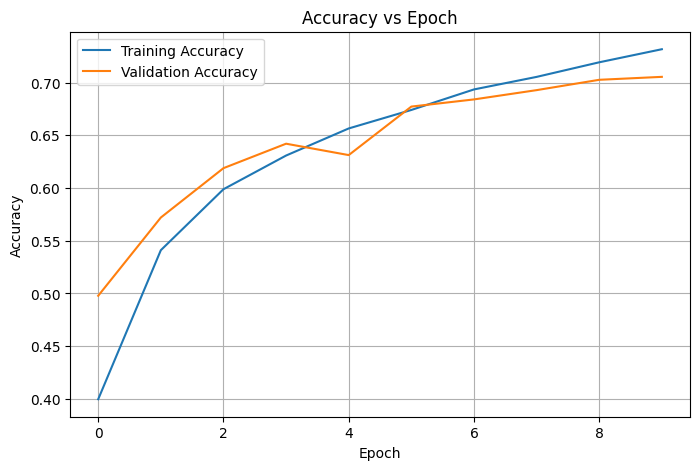

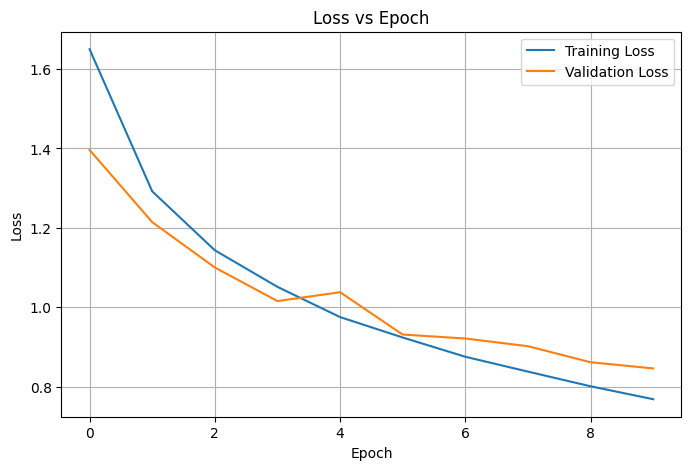

In [3]:
# ============================================================
# CNN IMAGE CLASSIFICATION
# TASK C: MODEL TRAINING AND EVALUATION
# Name     :  VETTRI SELVAN D
# Roll No  : 24BAD127
# ============================================================

# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

# Evaluate the model on testing data
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTesting Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

# Plot Accuracy vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# Plot Loss vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

PART D

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Classification Accuracy: 69.64 %


<Figure size 1000x800 with 0 Axes>

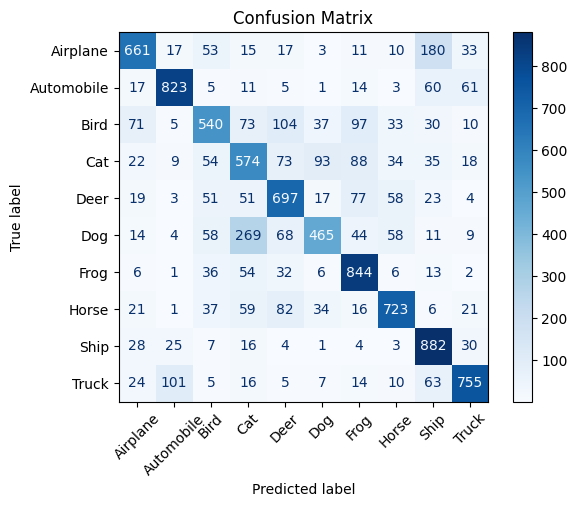

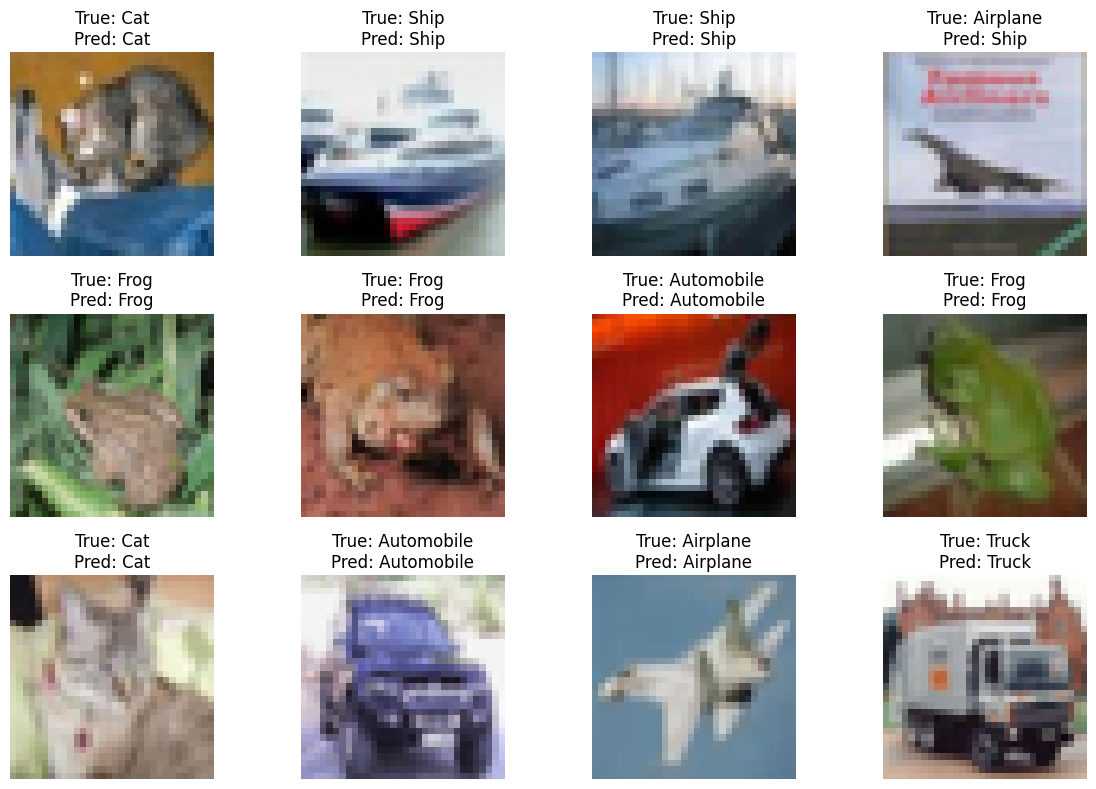

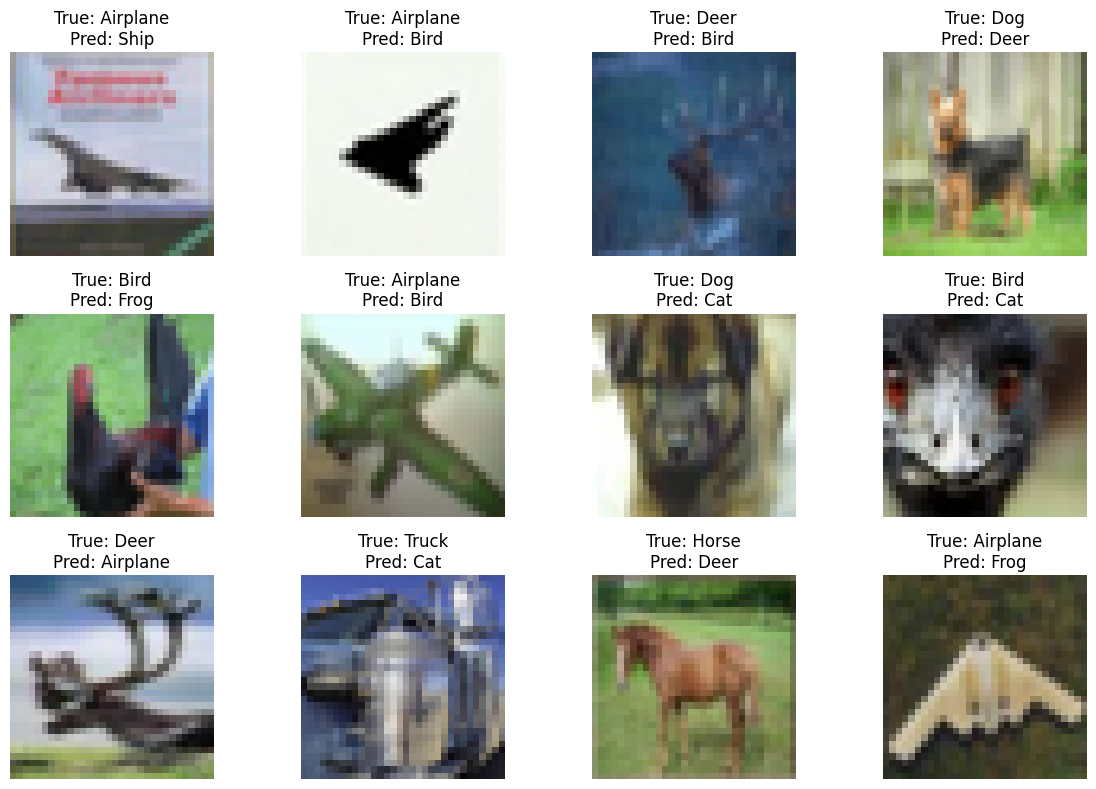

Number of Misclassified Images: 3036


In [4]:
# ============================================================
# CNN IMAGE CLASSIFICATION
# TASK D: PERFORMANCE ANALYSIS
# Name     :  VETTRI SELVAN D
# Roll No  : 24BAD127
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict classes
predictions = model.predict(x_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = y_test.flatten()

# Calculate testing accuracy
accuracy = np.mean(
    predicted_classes == true_classes
)

print("Classification Accuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

# Display sample predictions
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    true_label = class_names[true_classes[i]]
    predicted_label = class_names[predicted_classes[i]]

    plt.title(
        "True: " + true_label +
        "\nPred: " + predicted_label
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Find misclassified images
misclassified = np.where(
    predicted_classes != true_classes
)[0]

# Display misclassified images
plt.figure(figsize=(12, 8))

for i in range(min(12, len(misclassified))):

    index = misclassified[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    true_label = class_names[true_classes[index]]
    predicted_label = class_names[predicted_classes[index]]

    plt.title(
        "True: " + true_label +
        "\nPred: " + predicted_label
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("Number of Misclassified Images:", len(misclassified))